# Data preprocessing: Adult census income dataset

**ML-MDS 2026 - Elisa Müller and Berta Torrents**

## 0. Introduction

This notebook implements the preprocessing decisions identified during the exploratory data analysis (EDA) and prepares the dataset for the modeling phases. The transformations include handling invalid encoded values, imputing missing data through both deterministic rules and model-based methods, engineering derived features, and applying scaling and encoding to produce a clean, model-ready dataset.

A key consideration throughout the pipeline is the prevention of data leakage. Transformations that are based on fixed rules (such as replacing known invalid values or creating binary indicators) are applied before the train/test split, while any step that learns parameters from the data (imputation models, scaling statistics, encoder categories) is fit exclusively on the training set and then applied to both sets.

## 1. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATA_PATH = "adult.csv"
TARGET = "income"

# Plot configuration
PLOT_COLORS = {
    "neutral": "#FA8FB1",
    "neutral_light": "#7DB7FF",
    "income_low": "#2F80ED",
    "income_high": "#FF8A00",
    "before": "#7B8794",
    "after": "#00B894",
    "raw": "#7B8794",
    "transformed": "#00B894",
    "inlier": "#2F80ED",
    "outlier": "#E63946",
    "mild": "#F2C94C",
    "severe": "#E63946",
    "numerical": "#00B894",
    "categorical": "#9B51E0",
    "male": "#9B51E0",
    "female": "#FF5CA8",
    "reference": "#4A5568",
}
TARGET_PALETTE = {"<=50K": PLOT_COLORS["income_low"], ">50K": PLOT_COLORS["income_high"]}
TARGET_PALETTE_NUMERIC = {0: PLOT_COLORS["income_low"], 1: PLOT_COLORS["income_high"]}
FEATURE_TYPE_PALETTE = {"numerical": PLOT_COLORS["numerical"], "categorical": PLOT_COLORS["categorical"]}
PROCESS_PALETTE = {"Before": PLOT_COLORS["before"], "After": PLOT_COLORS["after"]}
TRANSFORM_PALETTE = {"Raw": PLOT_COLORS["raw"], "Transformed": PLOT_COLORS["transformed"]}
OUTLIER_PALETTE = {"Inlier": PLOT_COLORS["inlier"], "Outlier": PLOT_COLORS["outlier"]}
SEX_PALETTE = {"Male": PLOT_COLORS["male"], "Female": PLOT_COLORS["female"]}

sns.set_theme(
    style="whitegrid",
    palette=[PLOT_COLORS["neutral"], PLOT_COLORS["income_high"], PLOT_COLORS["after"], PLOT_COLORS["categorical"]],
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.edgecolor": "#D7DEE8",
        "axes.linewidth": 0.8,
        "grid.color": "#E8EDF3",
        "grid.linewidth": 0.7,
        "legend.frameon": False,
    },
)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.titlepad"] = 10


def polish_axes(ax, grid_axis="y"):
    ax.grid(False)
    ax.grid(True, axis=grid_axis, alpha=0.55)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    return ax

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)


In [2]:
df = pd.read_csv(DATA_PATH, na_values="?")

# Clean column names: strip whitespace, replace dots with underscores.
df.columns = df.columns.str.strip().str.replace(".", "_", regex=False)

# Strip leading/trailing whitespace from all string columns.
str_cols = df.select_dtypes(include=["object", "string"]).columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print(f"Raw shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Raw shape: (32561, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Invalid value handling

The EDA identified 159 rows where `capital_gain` has the value 99,999, significantly distant from the next highest genuine value (41,310). This represents an invalid encoded entry rather than a real observation. A binary indicator `capital_gain_is_99999` is created to preserve the information that an encoded value was originally present, and the 99,999 entries are then replaced with NaN.

In [3]:
# Create binary indicator BEFORE replacing, so the flag is preserved
df["capital_gain_is_99999"] = (df["capital_gain"] == 99999).astype(int)

# Replace invalid entries with NaN
n_invalid = (df["capital_gain"] == 99999).sum()
df.loc[df["capital_gain"] == 99999, "capital_gain"] = np.nan

print(f"Replaced {n_invalid} invalid capital_gain entries (99999) with NaN")
print(f"\ncapital_gain_is_99999 distribution:")
print(df["capital_gain_is_99999"].value_counts())
print(f"\ncapital_gain NaN count: {df['capital_gain'].isnull().sum()}")

Replaced 159 invalid capital_gain entries (99999) with NaN

capital_gain_is_99999 distribution:
capital_gain_is_99999
0    32402
1      159
Name: count, dtype: int64

capital_gain NaN count: 159


## 3. Deterministic missing value handling

The EDA showed that `workclass` and `occupation` are missing together on 1,809 rows, corresponding to individuals outside the labor force (retirees, students, homemakers). This is structural missingness, not random data loss. Imputing these values with existing employment categories would misrepresent these individuals by assigning them a work context they do not have. Hence, if an individual has both columns missing, both columns are filled with `"Unknown"` as an explicit new category that accurately reflects their situation.

The remaining missing values (`occupation` alone, `native_country`, and `capital_gain`) are not structural and will be handled through model-based imputation after the train/test split.

In [4]:
# Identify rows where both workclass and occupation are missing
both_missing = df["workclass"].isnull() & df["occupation"].isnull()

print(f"Rows with both workclass and occupation missing: {both_missing.sum()}")

# Fill with "Unknown" category
df.loc[both_missing, "workclass"] = "Unknown"
df.loc[both_missing, "occupation"] = "Unknown"

print(f"\nAfter filling with 'Unknown':")
print(f"  workclass NaN remaining: {df['workclass'].isnull().sum()}")
print(f"  occupation NaN remaining: {df['occupation'].isnull().sum()}")
print(f"  native_country NaN remaining: {df['native_country'].isnull().sum()}")
print(f"  capital_gain NaN remaining: {df['capital_gain'].isnull().sum()}")

Rows with both workclass and occupation missing: 1836

After filling with 'Unknown':
  workclass NaN remaining: 0
  occupation NaN remaining: 7
  native_country NaN remaining: 583
  capital_gain NaN remaining: 159


## 4. Pre-split feature engineering

This section creates derived features based on fixed rules established during the EDA. Since these transformations do not learn any parameters from the data, they can safely be applied before the train/test split without risk of data leakage.

### 4.1 `has_capital_activity`

The EDA showed that the distinction between zero and non-zero capital values carries strong predictive signal, with the >50K rate increasing substantially for individuals with non-zero `capital_gain` or `capital_loss`. A binary indicator is created to capture whether an individual has any investment activity at all.

The 159 rows where `capital_gain` was originally 99,999 (now `NaN`) are also set to `True`, since these individuals did have capital gains recorded. The exact amount is unknown but the presence of activity is certain.

In [5]:
# has_capital_activity: True if capital_gain > 0 OR capital_loss > 0 OR was 99999
df["has_capital_activity"] = (
    (df["capital_gain"] > 0) |
    (df["capital_loss"] > 0) |
    (df["capital_gain_is_99999"] == 1)
).astype(int)

print(f"has_capital_activity distribution:")
print(df["has_capital_activity"].value_counts())
print(f"\nPercentage with activity: {df['has_capital_activity'].mean()*100:.1f}%")

has_capital_activity distribution:
has_capital_activity
0    28330
1     4231
Name: count, dtype: int64

Percentage with activity: 13.0%


### 4.2 `is_higher_education`

The EDA showed a notable increase in the >50K rate starting at `education_num` >= 13, corresponding to Bachelor's degree and above. Hence, it is reasonable to construct a binary feature that separates individuals with higher education from the rest. Linear models treat `education_num` as a continuous variable and assume a constant effect for each additional year of education, but the data shows that the income benefit of education is not uniform, since it accelerates sharply at the Bachelor's threshold. This binary indicator allows linear models to capture that threshold effect directly.

In [6]:
df["is_higher_education"] = (df["education_num"] >= 13).astype(int)

print(f"is_higher_education distribution:")
print(df["is_higher_education"].value_counts())
print(f"\nPercentage with higher education: {df['is_higher_education'].mean()*100:.1f}%")

is_higher_education distribution:
is_higher_education
0    24494
1     8067
Name: count, dtype: int64

Percentage with higher education: 24.8%


### 4.3 `sex` to binary encoding

The feature `sex` is a binary variable with two values (`Male`, `Female`). Rather than creating two redundant one-hot columns, it is mapped directly to a single numeric column.

In [7]:
df["sex"] = df["sex"].map({"Male": 1, "Female": 0})

print(f"sex distribution after encoding:")
print(df["sex"].value_counts().rename({1: "Male (1)", 0: "Female (0)"}))

sex distribution after encoding:
sex
Male (1)      21790
Female (0)    10771
Name: count, dtype: int64


### 4.4 Drop `fnlwgt`

The EDA established that `fnlwgt` is a census sampling weight representing how many people in the population each record stands for. By its very nature, it is a property of the survey design rather than a characteristic of the individual, so it has no conceptual reason to predict income. The EDA confirmed this empirically: the distributions of `fnlwgt` for both income classes were virtually identical, and its statistical association with the target was the weakest among all features. Including it in the models would add noise without contributing any predictive signal, so it is dropped from the dataset.

In [8]:
df = df.drop(columns=["fnlwgt"])

print(f"Dropped 'fnlwgt'")
print(f"Shape: {df.shape}")

Dropped 'fnlwgt'
Shape: (32561, 17)


### 4.5 Summary of pre-split state

In [9]:
print(f"Shape after pre-split engineering: {df.shape}")
print(f"\nRemaining NaN counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nColumns:")
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    n_null = df[col].isnull().sum()
    null_str = f" ({n_null} NaN)" if n_null > 0 else ""
    print(f"  {i+1:2d}. {col:<25s} {str(dtype):<10s}{null_str}")

Shape after pre-split engineering: (32561, 17)

Remaining NaN counts:
occupation          7
capital_gain      159
native_country    583
dtype: int64

Columns:
   1. age                       int64     
   2. workclass                 str       
   3. education                 str       
   4. education_num             int64     
   5. marital_status            str       
   6. occupation                str        (7 NaN)
   7. relationship              str       
   8. race                      str       
   9. sex                       int64     
  10. capital_gain              float64    (159 NaN)
  11. capital_loss              int64     
  12. hours_per_week            int64     
  13. native_country            str        (583 NaN)
  14. income                    str       
  15. capital_gain_is_99999     int64     
  16. has_capital_activity      int64     
  17. is_higher_education       int64     


## 5. Target encoding

The target variable `income` is binarized, mapping `<=50K` to 0 and `>50K` to 1.

In [10]:
df[TARGET] = (df[TARGET] == ">50K").astype(int)

print(f"Target distribution after encoding:")
print(df[TARGET].value_counts().rename({0: "<=50K (0)", 1: ">50K (1)"}))
print(f"\nClass proportions:")
print(df[TARGET].value_counts(normalize=True).round(3).rename({0: "<=50K (0)", 1: ">50K (1)"}))

Target distribution after encoding:
income
<=50K (0)    24720
>50K (1)      7841
Name: count, dtype: int64

Class proportions:
income
<=50K (0)   0.759
>50K (1)    0.241
Name: proportion, dtype: float64


## 6. Train/test split

An 80/20 split is performed, forcing the class proportions to be maintained in both subsets. The split is done at this point, after deterministic transformations but before any model-based imputation or scaling, to prevent data leakage. All subsequent steps that learn parameters from the data are fit exclusively on the training set.

In [11]:
X = df.drop(columns=TARGET)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3).rename({0: "<=50K (0)", 1: ">50K (1)"}))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3).rename({0: "<=50K (0)", 1: ">50K (1)"}))

X_train shape: (26048, 16)
X_test shape:  (6513, 16)

Train target distribution:
income
<=50K (0)   0.759
>50K (1)    0.241
Name: proportion, dtype: float64

Test target distribution:
income
<=50K (0)   0.759
>50K (1)    0.241
Name: proportion, dtype: float64


## 7. Model-based imputation

The remaining missing values are imputed using Random Forest models, a state-of-the-art approach for tabular data imputation. Unlike simple mode or median imputation, Random Forest imputation leverages the relationships between features to produce predictions that respect the multivariate structure of the data. For each column with missing values, a Random Forest is trained on the rows where the value is present, using all other available features as predictors, and then used to predict the missing entries.

All models are fit exclusively on the training set and applied to both train and test to prevent data leakage. After imputation, the distributions before and after are compared to verify that the imputation has not distorted the original patterns.

The Random Forest imputer needs numeric input. Categorical features are temporarily label-encoded for use as predictors during imputation. This encoding is only used internally for the imputation step and is discarded afterwards.

In [12]:
# Save distributions before imputation for validation
cg_before_train = X_train["capital_gain"].copy()
cg_before_test = X_test["capital_gain"].copy()
occ_before_train = X_train["occupation"].copy()
occ_before_test = X_test["occupation"].copy()
nc_before_train = X_train["native_country"].copy()
nc_before_test = X_test["native_country"].copy()

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

cat_cols_for_encoding = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

for col in cat_cols_for_encoding:
    le = LabelEncoder()
    # Fit on all known (non-null) values from training set
    known_vals = X_train_imp.loc[X_train_imp[col].notna(), col]
    le.fit(known_vals)
    label_encoders[col] = le
    
    known_classes = set(le.classes_)
    
    for df_imp in [X_train_imp, X_test_imp]:
        mask = df_imp[col].notna()
        # Encode to a new float series, then replace the column entirely
        encoded = df_imp.loc[mask, col].apply(
            lambda x: le.transform([x])[0] if x in known_classes else le.transform([le.classes_[0]])[0]
        ).astype(float)
        # Replace column with float type (NaN-compatible)
        df_imp[col] = np.nan
        df_imp.loc[mask, col] = encoded

print("Label encoding applied for imputation.")
print(f"Encoded columns: {cat_cols_for_encoding}")

Label encoding applied for imputation.
Encoded columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


### 7.1 Impute `capital_gain` (numerical)

The 159 rows where `capital_gain` was originally 99,999 (replaced with `NaN` in Section 2) are imputed using a Random Forest Regressor. Since these individuals are known to have had capital gains, the model leverages the remaining features to estimate a plausible value based on the patterns observed in individuals with valid recorded gains.

In [14]:
# Store original distribution for validation (non-zero, non-NaN values from training)
cg_original_train = X_train.loc[
    (X_train["capital_gain"].notna()) & (X_train["capital_gain"] > 0),
    "capital_gain"
].copy()

# Identify predictor columns (all except capital_gain itself)
cg_predictors = [c for c in X_train_imp.columns if c != "capital_gain"]

# Split training data into rows with known and unknown capital_gain
cg_known_mask = X_train_imp["capital_gain"].notna()
cg_unknown_mask = ~cg_known_mask

print(f"Training rows with known capital_gain: {cg_known_mask.sum()}")
print(f"Training rows to impute: {cg_unknown_mask.sum()}")

# Train RF Regressor on rows where capital_gain is known
rf_cg = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Use only rows where ALL predictor values are also non-null
train_complete = X_train_imp.loc[cg_known_mask, cg_predictors].dropna()
train_target = X_train_imp.loc[train_complete.index, "capital_gain"]

rf_cg.fit(train_complete, train_target)
print(f"RF Regressor trained on {len(train_complete)} rows")

# Impute missing capital_gain in train
if cg_unknown_mask.sum() > 0:
    preds_train = rf_cg.predict(X_train_imp.loc[cg_unknown_mask, cg_predictors].fillna(0))
    X_train_imp.loc[cg_unknown_mask, "capital_gain"] = preds_train
    X_train.loc[cg_unknown_mask, "capital_gain"] = preds_train

# Impute missing capital_gain in test
cg_test_unknown = X_test_imp["capital_gain"].isnull()
if cg_test_unknown.sum() > 0:
    preds_test = rf_cg.predict(X_test_imp.loc[cg_test_unknown, cg_predictors].fillna(0))
    X_test_imp.loc[cg_test_unknown, "capital_gain"] = preds_test
    X_test.loc[cg_test_unknown, "capital_gain"] = preds_test

print(f"\nAfter imputation:")
print(f"  Train capital_gain NaN: {X_train['capital_gain'].isnull().sum()}")
print(f"  Test capital_gain NaN:  {X_test['capital_gain'].isnull().sum()}")

Training rows with known capital_gain: 25920
Training rows to impute: 128
RF Regressor trained on 25475 rows

After imputation:
  Train capital_gain NaN: 0
  Test capital_gain NaN:  0


### 7.2 Impute `occupation` (categorical)

Approximately 7 rows have `occupation` missing while `workclass` is present. Unlike the 1,809 rows handled in Section 3 where both employment columns were missing due to structural reasons, these individuals do have a known employment context. A Random Forest Classifier trained on the rows where occupation is known is used to predict the most likely occupation based on their remaining features.

In [15]:
# Store original distribution for validation
occ_original_train = X_train.loc[
    (X_train["occupation"].notna()) & (X_train["occupation"] != "Unknown"),
    "occupation"
].value_counts(normalize=True).copy()

# Predictor columns (all except occupation itself)
occ_predictors = [c for c in X_train_imp.columns if c != "occupation"]

# Identify rows to impute (NaN occupation)
occ_unknown_train = X_train_imp["occupation"].isnull()
occ_unknown_test = X_test_imp["occupation"].isnull()

print(f"Training rows to impute occupation: {occ_unknown_train.sum()}")
print(f"Test rows to impute occupation: {occ_unknown_test.sum()}")

if occ_unknown_train.sum() + occ_unknown_test.sum() > 0:
    # Train RF Classifier on rows where occupation is known (non-null)
    occ_known_mask = X_train_imp["occupation"].notna()
    train_complete = X_train_imp.loc[occ_known_mask, occ_predictors].dropna()
    train_target = X_train_imp.loc[train_complete.index, "occupation"]

    rf_occ = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_occ.fit(train_complete, train_target)
    print(f"RF Classifier trained on {len(train_complete)} rows")

    # Impute in train
    if occ_unknown_train.sum() > 0:
        preds_train = rf_occ.predict(X_train_imp.loc[occ_unknown_train, occ_predictors].fillna(0))
        # Decode back to original labels
        preds_decoded_train = label_encoders["occupation"].inverse_transform(preds_train.astype(int))
        X_train.loc[occ_unknown_train, "occupation"] = preds_decoded_train
        X_train_imp.loc[occ_unknown_train, "occupation"] = preds_train

    # Impute in test
    if occ_unknown_test.sum() > 0:
        preds_test = rf_occ.predict(X_test_imp.loc[occ_unknown_test, occ_predictors].fillna(0))
        preds_decoded_test = label_encoders["occupation"].inverse_transform(preds_test.astype(int))
        X_test.loc[occ_unknown_test, "occupation"] = preds_decoded_test
        X_test_imp.loc[occ_unknown_test, "occupation"] = preds_test
else:
    print("No occupation values to impute.")

print(f"\nAfter imputation:")
print(f"  Train occupation NaN: {X_train['occupation'].isnull().sum()}")
print(f"  Test occupation NaN:  {X_test['occupation'].isnull().sum()}")

Training rows to impute occupation: 4
Test rows to impute occupation: 3
RF Classifier trained on 25597 rows

After imputation:
  Train occupation NaN: 0
  Test occupation NaN:  0


### 7.3 Impute `native_country` (categorical)

The EDA showed that the 583 rows with missing `native_country` follow a largely independent and random missingness pattern. A Random Forest Classifier is used to impute the missing values based on the individual's other characteristics.

In [16]:
# Store original distribution for validation
nc_original_train = X_train.loc[
    X_train["native_country"].notna(),
    "native_country"
].value_counts(normalize=True).copy()

# Predictor columns
nc_predictors = [c for c in X_train_imp.columns if c != "native_country"]

# Identify rows to impute
nc_unknown_train = X_train_imp["native_country"].isnull()
nc_unknown_test = X_test_imp["native_country"].isnull()

print(f"Training rows to impute native_country: {nc_unknown_train.sum()}")
print(f"Test rows to impute native_country: {nc_unknown_test.sum()}")

# Train RF Classifier
nc_known_mask = X_train_imp["native_country"].notna()
train_complete = X_train_imp.loc[nc_known_mask, nc_predictors].dropna()
train_target = X_train_imp.loc[train_complete.index, "native_country"]

rf_nc = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_nc.fit(train_complete, train_target)
print(f"RF Classifier trained on {len(train_complete)} rows")

# Impute in train
if nc_unknown_train.sum() > 0:
    preds_train = rf_nc.predict(X_train_imp.loc[nc_unknown_train, nc_predictors].fillna(0))
    preds_decoded_train = label_encoders["native_country"].inverse_transform(preds_train.astype(int))
    X_train.loc[nc_unknown_train, "native_country"] = preds_decoded_train
    X_train_imp.loc[nc_unknown_train, "native_country"] = preds_train

# Impute in test
if nc_unknown_test.sum() > 0:
    preds_test = rf_nc.predict(X_test_imp.loc[nc_unknown_test, nc_predictors].fillna(0))
    preds_decoded_test = label_encoders["native_country"].inverse_transform(preds_test.astype(int))
    X_test.loc[nc_unknown_test, "native_country"] = preds_decoded_test
    X_test_imp.loc[nc_unknown_test, "native_country"] = preds_test

print(f"\nAfter imputation:")
print(f"  Train native_country NaN: {X_train['native_country'].isnull().sum()}")
print(f"  Test native_country NaN:  {X_test['native_country'].isnull().sum()}")

Training rows to impute native_country: 447
Test rows to impute native_country: 136
RF Classifier trained on 25601 rows

After imputation:
  Train native_country NaN: 0
  Test native_country NaN:  0


### 7.4 Imputation validation

To verify that the imputation has not distorted the original distributions, the following plots compare the distributions before and after imputation for each imputed column. If the imputation is faithful to the underlying data, the before and after distributions should look similar.

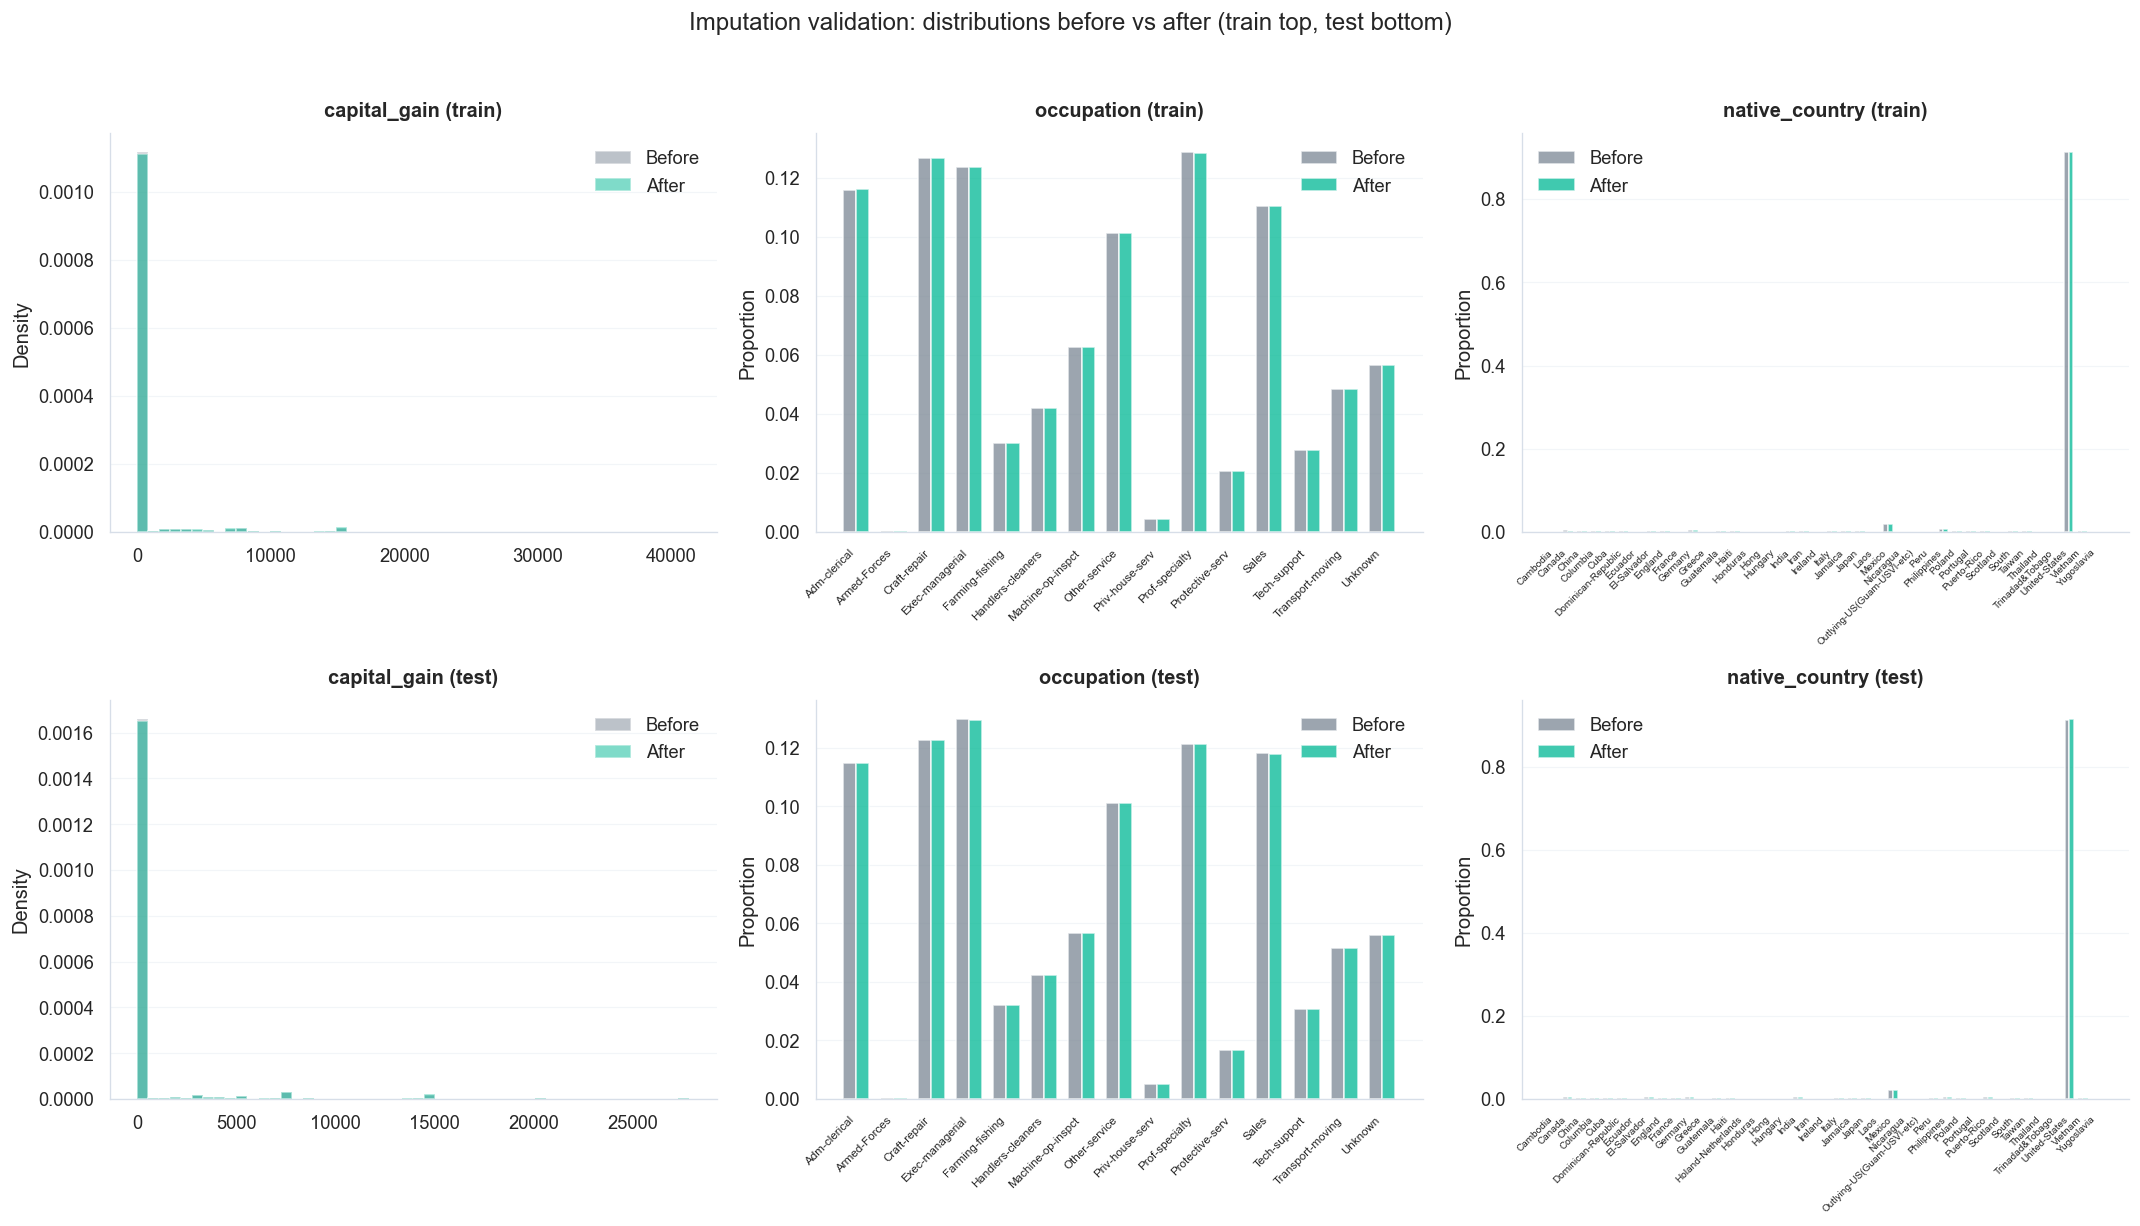

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- TRAIN (top row) ---

# capital_gain
ax = axes[0, 0]
ax.hist(cg_before_train.dropna(), bins=50, alpha=0.5, color=PROCESS_PALETTE["Before"], label="Before", density=True)
ax.hist(X_train["capital_gain"], bins=50, alpha=0.5, color=PROCESS_PALETTE["After"], label="After", density=True)
ax.set_title("capital_gain (train)")
ax.set_ylabel("Density")
ax.legend()
polish_axes(ax)

# occupation
ax = axes[0, 1]
occ_before = occ_before_train.value_counts(normalize=True, dropna=True)
occ_after = X_train["occupation"].value_counts(normalize=True)
all_occ = sorted(set(occ_before.index) | set(occ_after.index))
x = np.arange(len(all_occ))
width = 0.35
ax.bar(x - width/2, [occ_before.get(c, 0) for c in all_occ], width, label="Before", color=PROCESS_PALETTE["Before"], alpha=0.75)
ax.bar(x + width/2, [occ_after.get(c, 0) for c in all_occ], width, label="After", color=PROCESS_PALETTE["After"], alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(all_occ, rotation=45, ha="right", fontsize=7)
ax.set_title("occupation (train)")
ax.set_ylabel("Proportion")
ax.legend()
polish_axes(ax)

# native_country
ax = axes[0, 2]
nc_before = nc_before_train.value_counts(normalize=True, dropna=True)
nc_after = X_train["native_country"].value_counts(normalize=True)
all_countries = sorted(set(nc_before.index) | set(nc_after.index))
x_nc = np.arange(len(all_countries))
ax.bar(x_nc - width/2, [nc_before.get(c, 0) for c in all_countries], width, label="Before", color=PROCESS_PALETTE["Before"], alpha=0.75)
ax.bar(x_nc + width/2, [nc_after.get(c, 0) for c in all_countries], width, label="After", color=PROCESS_PALETTE["After"], alpha=0.75)
ax.set_xticks(x_nc)
ax.set_xticklabels(all_countries, rotation=45, ha="right", fontsize=6)
ax.set_title("native_country (train)")
ax.set_ylabel("Proportion")
ax.legend()
polish_axes(ax)

# --- TEST (bottom row) ---

# capital_gain
ax = axes[1, 0]
ax.hist(cg_before_test.dropna(), bins=50, alpha=0.5, color=PROCESS_PALETTE["Before"], label="Before", density=True)
ax.hist(X_test["capital_gain"], bins=50, alpha=0.5, color=PROCESS_PALETTE["After"], label="After", density=True)
ax.set_title("capital_gain (test)")
ax.set_ylabel("Density")
ax.legend()
polish_axes(ax)

# occupation
ax = axes[1, 1]
occ_before_t = occ_before_test.value_counts(normalize=True, dropna=True)
occ_after_t = X_test["occupation"].value_counts(normalize=True)
all_occ_t = sorted(set(occ_before_t.index) | set(occ_after_t.index))
x_t = np.arange(len(all_occ_t))
ax.bar(x_t - width/2, [occ_before_t.get(c, 0) for c in all_occ_t], width, label="Before", color=PROCESS_PALETTE["Before"], alpha=0.75)
ax.bar(x_t + width/2, [occ_after_t.get(c, 0) for c in all_occ_t], width, label="After", color=PROCESS_PALETTE["After"], alpha=0.75)
ax.set_xticks(x_t)
ax.set_xticklabels(all_occ_t, rotation=45, ha="right", fontsize=7)
ax.set_title("occupation (test)")
ax.set_ylabel("Proportion")
ax.legend()
polish_axes(ax)

# native_country
ax = axes[1, 2]
nc_before_t = nc_before_test.value_counts(normalize=True, dropna=True)
nc_after_t = X_test["native_country"].value_counts(normalize=True)
all_countries_t = sorted(set(nc_before_t.index) | set(nc_after_t.index))
x_nc_t = np.arange(len(all_countries_t))
ax.bar(x_nc_t - width/2, [nc_before_t.get(c, 0) for c in all_countries_t], width, label="Before", color=PROCESS_PALETTE["Before"], alpha=0.75)
ax.bar(x_nc_t + width/2, [nc_after_t.get(c, 0) for c in all_countries_t], width, label="After", color=PROCESS_PALETTE["After"], alpha=0.75)
ax.set_xticks(x_nc_t)
ax.set_xticklabels(all_countries_t, rotation=45, ha="right", fontsize=6)
ax.set_title("native_country (test)")
ax.set_ylabel("Proportion")
ax.legend()
polish_axes(ax)

plt.suptitle("Imputation validation: distributions before vs after (train top, test bottom)", y=1.02)
plt.tight_layout()
plt.show()


The histograms and proportion charts show that the distributions before and after imputation remain consistent across all three imputed columns in both the training and test sets. The overall shape of `capital_gain` is preserved, and the category proportions for `occupation` and `native_country` are practically identical. The imputation is therefore accepted for both train and test.

## 8. Post-imputation feature engineering

With all missing values resolved, the remaining derived features can now be created. These features depend on the imputed values and could not be computed earlier in the pipeline.

### 8.1 `native_country` to binary `is_US`

The EDA showed that `native_country` is dominated by United-States (almost 90% of observations have this category), with no other country exceeding 2% of the dataset, and its association with income was among the weakest of all features. The meaningful signal is simply whether the individual was born in the US or not. The original `native_country` column is therefore replaced with a single binary feature that expresses whether the individual's country of origin is the United States.

In [18]:
for df_split in [X_train, X_test]:
    df_split["is_US"] = (df_split["native_country"] == "United-States").astype(int)
    df_split.drop(columns=["native_country"], inplace=True)

print("Converted native_country → is_US")
print(f"\nTrain is_US distribution:")
print(X_train["is_US"].value_counts().rename({1: "US (1)", 0: "Non-US (0)"}))
print(f"\nTest is_US distribution:")
print(X_test["is_US"].value_counts().rename({1: "US (1)", 0: "Non-US (0)"}))

Converted native_country → is_US

Train is_US distribution:
is_US
US (1)        23752
Non-US (0)     2296
Name: count, dtype: int64

Test is_US distribution:
is_US
US (1)        5956
Non-US (0)     557
Name: count, dtype: int64


### 8.2 Log-transform in capital columns

The raw `capital_gain` and `capital_loss` columns are extremely zero-inflated and right-skewed. The `log1p(x) = log(1 + x)` transformation handles zeros gracefully and compresses the heavy right tail, producing a distribution more suitable for linear models and distance-based methods.

Log-transformed capital columns created.

Train capital_gain_log - min: 0.000, max: 10.629, median: 0.000
Train capital_loss_log - min: 0.000, max: 8.380, median: 0.000


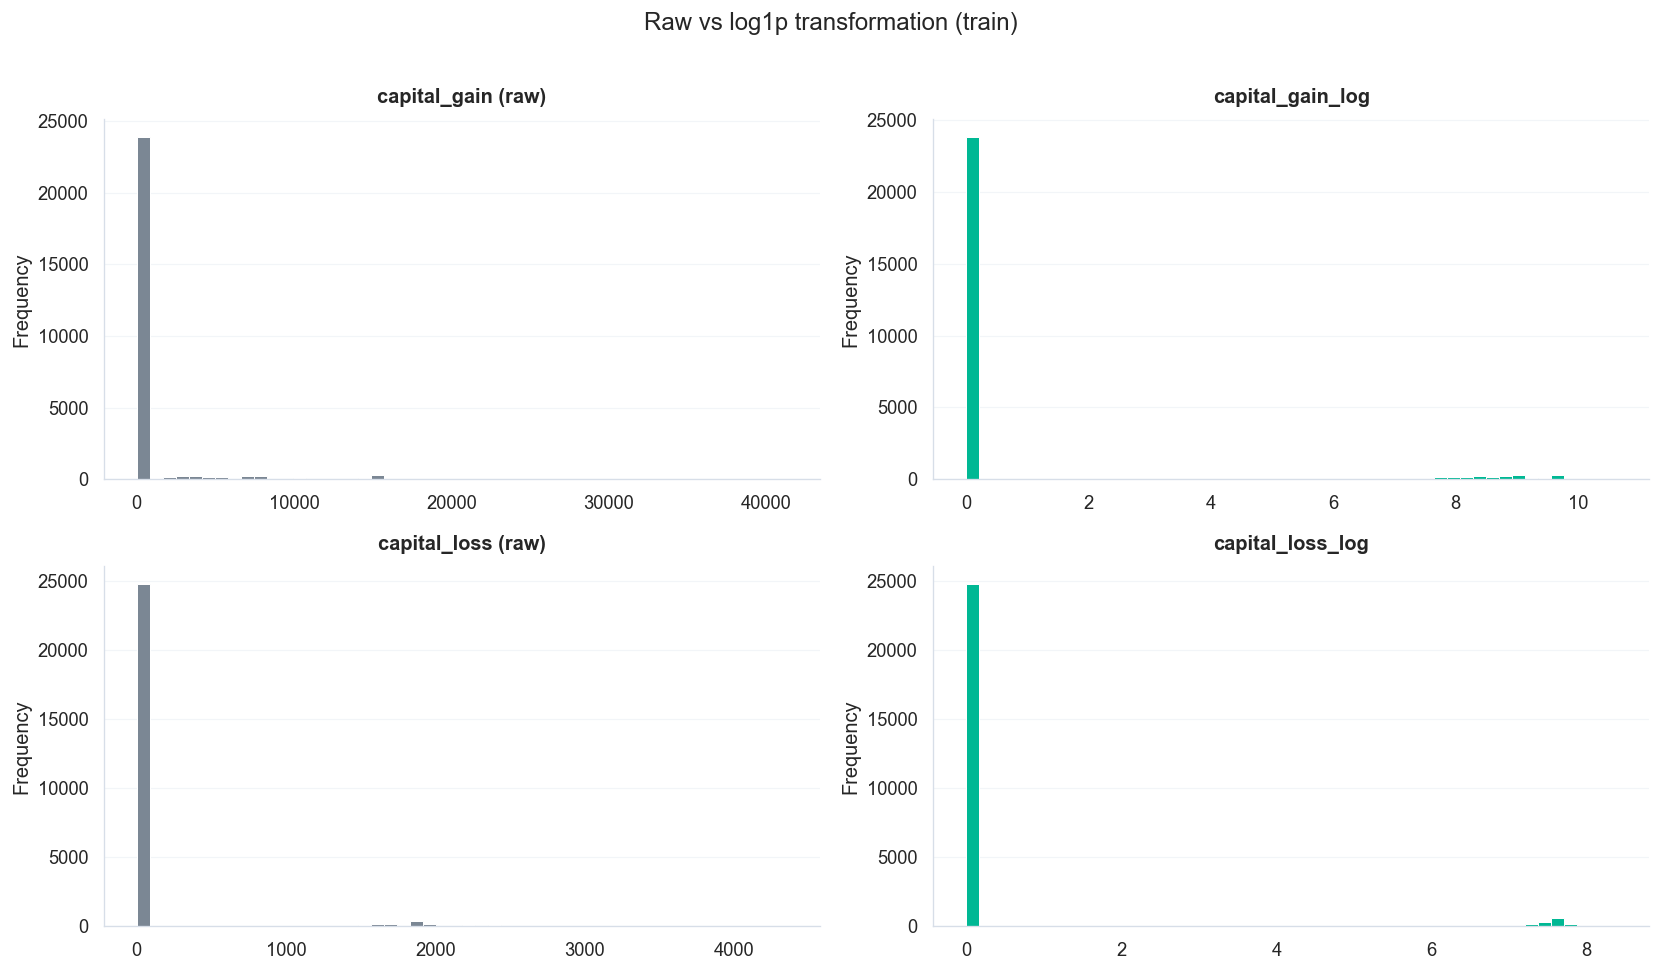

In [19]:
for df_split in [X_train, X_test]:
    df_split["capital_gain_log"] = np.log1p(df_split["capital_gain"])
    df_split["capital_loss_log"] = np.log1p(df_split["capital_loss"])

print("Log-transformed capital columns created.")
print(f"\nTrain capital_gain_log - min: {X_train['capital_gain_log'].min():.3f}, "
      f"max: {X_train['capital_gain_log'].max():.3f}, "
      f"median: {X_train['capital_gain_log'].median():.3f}")
print(f"Train capital_loss_log - min: {X_train['capital_loss_log'].min():.3f}, "
      f"max: {X_train['capital_loss_log'].max():.3f}, "
      f"median: {X_train['capital_loss_log'].median():.3f}")

# Histogram comparison: raw vs log-transformed
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ax = axes[0, 0]
ax.hist(X_train["capital_gain"], bins=50, color=TRANSFORM_PALETTE["Raw"], edgecolor="white", linewidth=0.6)
ax.set_title("capital_gain (raw)")
ax.set_ylabel("Frequency")
polish_axes(ax)

ax = axes[0, 1]
ax.hist(X_train["capital_gain_log"], bins=50, color=TRANSFORM_PALETTE["Transformed"], edgecolor="white", linewidth=0.6)
ax.set_title("capital_gain_log")
ax.set_ylabel("Frequency")
polish_axes(ax)

ax = axes[1, 0]
ax.hist(X_train["capital_loss"], bins=50, color=TRANSFORM_PALETTE["Raw"], edgecolor="white", linewidth=0.6)
ax.set_title("capital_loss (raw)")
ax.set_ylabel("Frequency")
polish_axes(ax)

ax = axes[1, 1]
ax.hist(X_train["capital_loss_log"], bins=50, color=TRANSFORM_PALETTE["Transformed"], edgecolor="white", linewidth=0.6)
ax.set_title("capital_loss_log")
ax.set_ylabel("Frequency")
polish_axes(ax)

plt.suptitle("Raw vs log1p transformation (train)", y=1.01)
plt.tight_layout()
plt.show()


Even after the log transformation, the distributions remain heavily right-skewed, with the vast majority of observations concentrated at zero. This suggests that the continuous versions of these features may offer limited value to the models compared to the binary `has_capital_activity` indicator constructed before, which directly captures the most informative signal. Both representations are kept in the dataset so that the models can determine which form is more useful during training.

### 8.3 Net capital balance

A new feature `net_capital` is created as the difference between `capital_gain` and `capital_loss`. Instead of treating gains and losses as independent signals, this feature combines them into a single measure that reflects the individual's overall financial balance during the tax year. A positive value indicates net gains, a negative value indicates net losses, and zero indicates no investment activity or a balanced position. This consolidated representation may help models that benefit from having a single financial summary rather than two separate sparse columns.

Additionally, a categorical feature `capital_direction` is derived from `net_capital` to capture the direction of financial activity: `"gain"` for individuals with positive net capital, `"loss"` for those with negative net capital, and `"none"` for those with no investment activity. This three-level representation may be more informative than the binary `has_capital_activity` varaible.

In [20]:
for df_split in [X_train, X_test]:
    df_split["net_capital"] = df_split["capital_gain"] - df_split["capital_loss"]
    df_split["capital_direction"] = np.where(
        df_split["net_capital"] > 0, "gain",
        np.where(df_split["net_capital"] < 0, "loss", "none")
    )

print("net_capital and capital_direction created.")
print(f"\nTrain net_capital - min: {X_train['net_capital'].min():.1f}, "
      f"max: {X_train['net_capital'].max():.1f}, "
      f"mean: {X_train['net_capital'].mean():.1f}, "
      f"median: {X_train['net_capital'].median():.1f}")
print(f"\nTrain capital_direction distribution:")
print(X_train["capital_direction"].value_counts())

net_capital and capital_direction created.

Train net_capital - min: -4356.0, max: 41310.0, mean: 559.4, median: 0.0

Train capital_direction distribution:
capital_direction
none    22637
gain     2179
loss     1232
Name: count, dtype: int64


### 8.4 Age and hours interaction

The EDA showed that `age` and `hours_per_week` interact in their relationship with income: working long hours is associated with high income primarily during peak career years (30-55), while young or elderly individuals working the same hours are much less likely to earn above 50K. Linear models treat each feature independently and cannot capture this joint effect on their own. By multiplying `age` by `hours_per_week`, the resulting feature encodes a combined signal where high values correspond to middle-aged individuals working long hours, which is precisely the profile most associated with high income in the EDA.

age_x_hours created.

Train age_x_hours - min: 21, max: 8910, mean: 1568, median: 1520


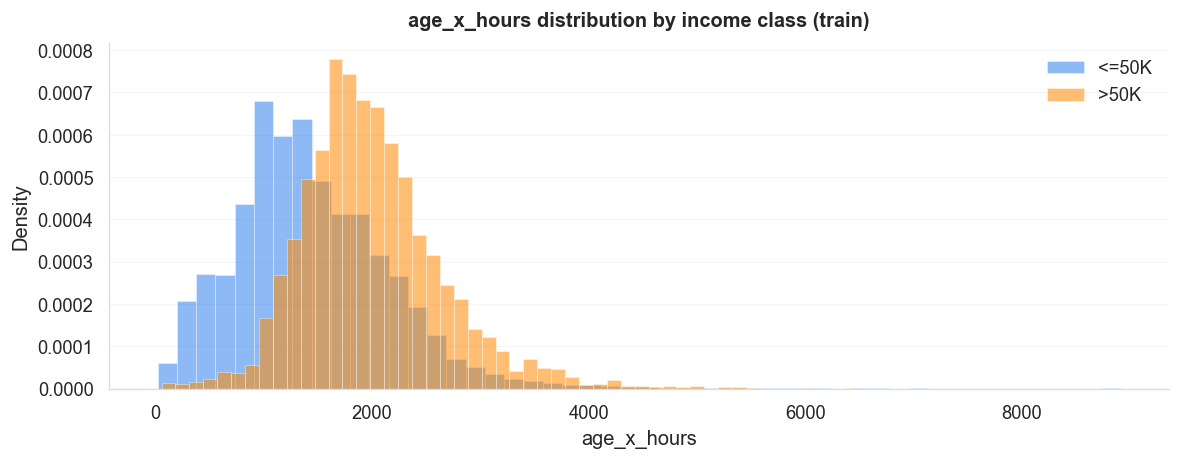

In [21]:
for df_split in [X_train, X_test]:
    df_split["age_x_hours"] = df_split["age"] * df_split["hours_per_week"]

print("age_x_hours created.")
print(f"\nTrain age_x_hours - min: {X_train['age_x_hours'].min():.0f}, "
      f"max: {X_train['age_x_hours'].max():.0f}, "
      f"mean: {X_train['age_x_hours'].mean():.0f}, "
      f"median: {X_train['age_x_hours'].median():.0f}")

# Histogram of the new feature by income class
fig, ax = plt.subplots(figsize=(10, 4))
for label, color in TARGET_PALETTE_NUMERIC.items():
    subset = X_train.loc[y_train == label, "age_x_hours"]
    ax.hist(subset, bins=50, alpha=0.55, color=color, label=f"{'<=50K' if label == 0 else '>50K'}", density=True, edgecolor="white", linewidth=0.4)
ax.set_title("age_x_hours distribution by income class (train)")
ax.set_xlabel("age_x_hours")
ax.set_ylabel("Density")
ax.legend()
polish_axes(ax)
plt.tight_layout()
plt.show()


The histogram confirms the interaction effect identified in the EDA. The `<=50K` group peaks at lower `age_x_hours` values (around 800-1200, corresponding to younger individuals or those working fewer hours), while the `>50K` group peaks higher (around 1600-2000, corresponding to middle-aged individuals working full-time or overtime). The two distributions show a clear shift, with the `>50K` class concentrated further to the right, indicating that this feature effectively separates the two income classes. The overlap region is smaller than what either `age` or `hours_per_week` would produce individually, suggesting that the interaction captures combined information that the original features alone do not provide.

### 8.5 Drop raw capital columns

The raw `capital_gain` and `capital_loss` columns are dropped at this point. With over 90% of their values being zero, these columns are extremely sparse: most of the entries carry no information, and the few non-zero values span a wide range that creates difficulties for distance-based and linear models. Rather than keeping these problematic raw columns, the pipeline has already extracted their useful information through multiple derived features: `capital_gain_log` and `capital_loss_log` compress the skewed tail for the minority of non-zero observations, `net_capital` and `capital_direction` summarize the overall financial position, `has_capital_activity` captures the binary signal that the EDA identified as the strongest predictor among all capital-related features, and `capital_gain_is_99999` flags the originally invalid entries. Together, these derived features represent the same underlying information in a form that is more accessible to the models.

In [22]:
for df_split in [X_train, X_test]:
    df_split.drop(columns=["capital_gain", "capital_loss"], inplace=True)

print("Dropped raw capital_gain and capital_loss.")
print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

Dropped raw capital_gain and capital_loss.

Train shape: (26048, 19)
Test shape:  (6513, 19)


### 8.6 Column inventory after feature engineering

In [23]:
print("Current columns after all feature engineering:")
for i, col in enumerate(X_train.columns):
    dtype = X_train[col].dtype
    n_unique = X_train[col].nunique()
    n_null = X_train[col].isnull().sum()
    null_str = f" ({n_null} NaN)" if n_null > 0 else ""
    print(f"  {i+1:2d}. {col:<25s} dtype={str(dtype):<10s} unique={n_unique}{null_str}")

Current columns after all feature engineering:
   1. age                       dtype=int64      unique=73
   2. workclass                 dtype=str        unique=9
   3. education                 dtype=str        unique=16
   4. education_num             dtype=int64      unique=16
   5. marital_status            dtype=str        unique=7
   6. occupation                dtype=str        unique=15
   7. relationship              dtype=str        unique=6
   8. race                      dtype=str        unique=5
   9. sex                       dtype=int64      unique=2
  10. hours_per_week            dtype=int64      unique=91
  11. capital_gain_is_99999     dtype=int64      unique=2
  12. has_capital_activity      dtype=int64      unique=2
  13. is_higher_education       dtype=int64      unique=2
  14. is_US                     dtype=int64      unique=2
  15. capital_gain_log          dtype=float64    unique=242
  16. capital_loss_log          dtype=float64    unique=89
  17. net_capital

## 9. Preprocessing pipeline

## 9. Preprocessing pipeline

A scikit-learn `ColumnTransformer` is built with separate pipelines for three types of features. The pipeline learns its transformation parameters exclusively from the training data and then applies those same parameters to both the train and test sets, ensuring no information from the test set influences the preprocessing.

- **Continuous numerical pipeline:** `StandardScaler` normalizes each feature to zero mean and unit variance, using the mean and standard deviation computed on the training set. This is essential for linear models, kernel SVMs, and PCA, which are sensitive to feature scale.
- **Categorical pipeline:** `OneHotEncoder` creates binary columns for each category observed in the training set. The `handle_unknown="ignore"` parameter ensures that if the test set contains a category not seen during training, it produces a zero-vector instead of raising an error.
- **Binary features:** passed through without transformation. These features are categorical varaibles but encoded as 0-1, so do not require normalization nor encoding.

In [24]:
# Define feature groups
continuous_features = [
    "age",
    "education_num",
    "hours_per_week",
    "capital_gain_log",
    "capital_loss_log",
    "net_capital",
    "age_x_hours",
]

binary_features = [
    "sex",
    "capital_gain_is_99999",
    "has_capital_activity",
    "is_higher_education",
    "is_US",
]

categorical_features = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "capital_direction",
]

In [25]:
# Build pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_features),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
)

# Fit on training data, transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrames
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index,
)
X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index,
)

print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape:  {X_test_processed.shape}")
print(f"Total features after encoding: {X_train_processed.shape[1]}")

Processed train shape: (26048, 73)
Processed test shape:  (6513, 73)
Total features after encoding: 73


In [26]:
# List all final feature names
print(f"Final feature names ({len(feature_names)}):")
for i, name in enumerate(feature_names):
    print(f"{i+1:2d}. {name}")

Final feature names (73):
 1. num__age
 2. num__education_num
 3. num__hours_per_week
 4. num__capital_gain_log
 5. num__capital_loss_log
 6. num__net_capital
 7. num__age_x_hours
 8. bin__sex
 9. bin__capital_gain_is_99999
10. bin__has_capital_activity
11. bin__is_higher_education
12. bin__is_US
13. cat__workclass_Federal-gov
14. cat__workclass_Local-gov
15. cat__workclass_Never-worked
16. cat__workclass_Private
17. cat__workclass_Self-emp-inc
18. cat__workclass_Self-emp-not-inc
19. cat__workclass_State-gov
20. cat__workclass_Unknown
21. cat__workclass_Without-pay
22. cat__education_10th
23. cat__education_11th
24. cat__education_12th
25. cat__education_1st-4th
26. cat__education_5th-6th
27. cat__education_7th-8th
28. cat__education_9th
29. cat__education_Assoc-acdm
30. cat__education_Assoc-voc
31. cat__education_Bachelors
32. cat__education_Doctorate
33. cat__education_HS-grad
34. cat__education_Masters
35. cat__education_Preschool
36. cat__education_Prof-school
37. cat__education_So

## 10. Validation and export

### 10.1 Validation checks

In [27]:
# No missing values
train_nan = X_train_processed.isnull().sum().sum()
test_nan = X_test_processed.isnull().sum().sum()
print(f"NaN values in processed train: {train_nan}")
print(f"NaN values in processed test:  {test_nan}")

# Numeric features are scaled
print(f"\nNumeric feature scaling verification (train set):")
num_cols_processed = [c for c in feature_names if c.startswith("num__")]
if len(num_cols_processed) > 0:
    stats = X_train_processed[num_cols_processed].agg(["mean", "std"]).round(4)
    print(stats)

# Class proportions preserved
print(f"\nClass proportions preserved:")
print(f"Full dataset: {y.mean():.4f}")
print(f"Train set: {y_train.mean():.4f}")
print(f"Test set: {y_test.mean():.4f}")

# No index overlap
overlap = set(X_train.index) & set(X_test.index)
print(f"\nIndex overlap between train and test: {len(overlap)} (should be 0)")

NaN values in processed train: 0
NaN values in processed test:  0

Numeric feature scaling verification (train set):
      num__age  num__education_num  num__hours_per_week  \
mean     0.000               0.000               -0.000   
std      1.000               1.000                1.000   

      num__capital_gain_log  num__capital_loss_log  num__net_capital  \
mean                 -0.000                  0.000            -0.000   
std                   1.000                  1.000             1.000   

      num__age_x_hours  
mean            -0.000  
std              1.000  

Class proportions preserved:
Full dataset: 0.2408
Train set: 0.2408
Test set: 0.2407

Index overlap between train and test: 0 (should be 0)


### 10.2 Transformation summary

In [28]:
print("PREPROCESSING SUMMARY")
print(f"\nRaw dataset: 32,561 rows and 15 columns")
print(f"After preprocessing: {X_train_processed.shape[0]} train + {X_test_processed.shape[0]} test")
print(f"Final features: {X_train_processed.shape[1]}")

PREPROCESSING SUMMARY

Raw dataset: 32,561 rows and 15 columns
After preprocessing: 26048 train + 6513 test
Final features: 73


### 10.3 Save outputs

In [29]:
# Save processed data
X_train_processed.to_csv("adult_X_train.csv", index=True)
X_test_processed.to_csv("adult_X_test.csv", index=True)
y_train.to_csv("adult_y_train.csv", index=True)
y_test.to_csv("adult_y_test.csv", index=True)

# Save the fitted preprocessor for consistent transformation
joblib.dump(preprocessor, "preprocessor.joblib")

print("Saved files: adult_X_train.csv, adult_X_test.csv, adult_y_train.csv, adult_y_test.csv, preprocessor.joblib")

Saved files: adult_X_train.csv, adult_X_test.csv, adult_y_train.csv, adult_y_test.csv, preprocessor.joblib
